<div style="background-color: black; color: white; padding: 10px;text-align: center;">
  <strong>Date Published:</strong> Jun 13, 2026 <strong>Author:</strong> Adnan Alaref
</div>

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 1: Import Library.</div>

In [1]:
import re
import os
import cv2
import torch
import numpy as np
import seaborn as sns
import torch.nn as nn
from pathlib import Path
from pprint import pprint
from tqdm.auto import tqdm
from PIL import Image, ImageOps
from collections import Counter
import matplotlib.pyplot as plt
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from typing import Dict, List, TypeVar, Tuple, Any
from sklearn.metrics import f1_score, classification_report

import warnings
warnings.simplefilter(action='ignore')
warnings.filterwarnings(action='ignore', category=FutureWarning)

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 2: Collect Person Crops From Middle Image.</div>

In [2]:
# from google.colab import drive
# drive.mount(r'/content/drive')
dataset_root = r"/kaggle/input/group-activity-recognition-volleyball"

In [3]:
from collections import OrderedDict
def collect_person_data(videos_root:str,
                        split_group:List[int]
                        )->OrderedDict[str, Tuple[str, List[Tuple[Tuple[int, int, int, int], str]]]]:
  """
    Collects person annotation data from multiple video folders.

    Args:
        videos_root (str): Path to the root directory containing video folders.
        split_group (List[int]): List of video IDs to process.

    Returns:
        OrderedDict[str, Tuple[str, List[Tuple[Tuple[int,int,int,int], str]]]]:
            Mapping from clip_ID (str) to a tuple containing:
                - group_action (str)
                - list of (bbox, player_action) tuples
    Raises:
        FileNotFoundError: If videos_root or any annotation file does not exist.
  """
  if not os.path.isdir(videos_root):
    raise FileNotFoundError(f"Expected directory does not exist.\nPath: {videos_root}")

  # Initialize ordered dict to store annotations
  videos_annotations:OrderedDict[str, Tuple[str, List[Tuple[Tuple[int, int, int, int], str]]]] = OrderedDict()

  for video_id in split_group:
    # Step 1: Get annotations.txt for each video_id
    video_annot = os.path.join(videos_root, str(video_id), 'annotations.txt')
    if not os.path.isfile(video_annot):
      raise FileNotFoundError(f"Video annotation file does not exist.: \nPath: {video_annot}")

    # Step 2: Read and process each line in the annotation file
    with open(video_annot, mode='r') as file:
      for line in file:
        line = line.strip()
        if not line:
          continue # skip empty lines

        parts = line.split()
        frame_ID, group_action = parts[0], parts[1]

        # Remove file extension to get clip_ID
        clip_ID = re.sub(r'\.[a-zA-Z]+$', '', frame_ID, flags=re.IGNORECASE)
        # Remaining parts contain bbox coordinates + player actions
        data_parts = parts[2:]
        bboxes:List[Tuple[Tuple[int, int, int, int], str]] = []

        # Step 2.1: Parse bboxes and corresponding actions
        # Each bbox has 4 numbers, followed by 1 player_action
        for idx in range(0, len(data_parts), 5):
          player_box = tuple(map(int, data_parts[idx:idx+4]))
          player_action = data_parts[idx + 4]
          bboxes.append((player_box, player_action))

        # Step 3: Store collected data in the OrderedDict
        frame_path = os.path.join(videos_root, str(video_id), clip_ID, frame_ID)
        videos_annotations[frame_path] = (group_action, bboxes)

  return videos_annotations

(1280, 720)


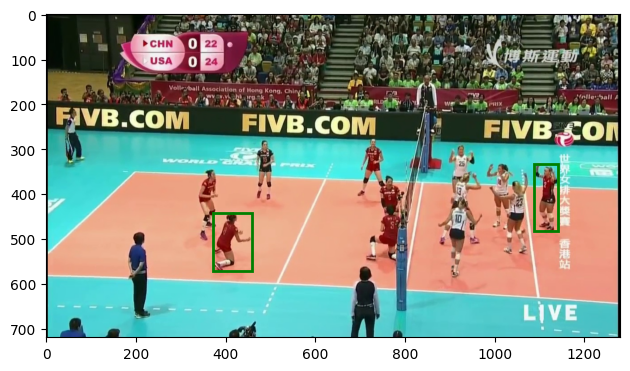

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

players_data = collect_person_data(os.path.join(dataset_root,'videos'), [0,1])
dd = list(players_data.items())[:1]

img = Image.open(r"/kaggle/input/group-activity-recognition-volleyball/videos/0/48075/48075.jpg")
x, y, w, h = dd[0][1][1][0][0]
x1, y1, w1, h1 = dd[0][1][1][6][0]
print(img.size)

fig, ax = plt.subplots()
ax.imshow(img)
ax.add_patch(patches.Rectangle(
    (x, y), w, h, linewidth=2, edgecolor='g', facecolor='none'
))
ax.add_patch(patches.Rectangle(
    (x1, y1), w1, h1, linewidth=2, edgecolor='g', facecolor='none'
))
plt.tight_layout()
plt.show()

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 3: Create Custom Dateset.</div>

In [5]:
def build_samples(videos_annotations_datas:OrderedDict)->List[Tuple[str, str, Tuple[int, int, int, int], str]]:
  samples = []
  videos_annotations_data_list = list(videos_annotations_datas.items())
  for frame_path, (group_action, players) in videos_annotations_data_list:
    for bbox, player_action in players:
      samples.append((frame_path, group_action, bbox, player_action))
  return samples

In [6]:
class Person_activity_Dataset(Dataset):
  def __init__(self, videos_annotations_data:OrderedDict, transform = None) -> None:
    super().__init__()
    self.transform = transform
    self.samples = build_samples(videos_annotations_data)
    self.categorical_labels = [label for _, _, _, label in self.samples]

    # Fixed class list
    Person_activity_classes = ["standing", "moving", "waiting", "blocking",  "digging", "setting", "falling", "spiking", "jumping"]
    self.Person_action2idx = {action:idx for idx, action in enumerate(Person_activity_classes)}
    self.Person_idx2action = {idx:action for action, idx in self.Person_action2idx.items()}
    self.labels = [self.Person_action2idx[label] for label in self.categorical_labels]

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, index:int):
    frame_path, _, bbox, person_action = self.samples[index]
    try:
      with Image.open(frame_path) as image:
        image = ImageOps.exif_transpose(image) # safe, no-op here
        image = image.convert('RGB')
        W, H = image.size

        x1, y1, w, h = bbox
        x2 = x1 + w
        y2 = y1 + h

        # Clamp to image bounds
        x1, x2 = max(0, min(x1,W-1)), max(0, min(x2, W))
        y1, y2 = max(0, min(y1,H-1)), max(0, min(y2, H))

        person_crop = image.crop((x1, y1, x2, y2)) # .crop() we use PIL not cv2

    except Exception as e:
      raise RuntimeError(f"Warning: Failed to process {frame_path}") from e

    # Apply transform if defined
    if self.transform:
      person_crop = self.transform(person_crop)

    person_label = torch.tensor(self.labels[index], dtype=torch.long)
    return person_crop, person_label

  @property
  def summary(self):
    act_map = dict(Counter(self.categorical_labels))
    print("="*40)
    print(f"Total crops      : {len(self.samples)}")
    print(f"Unique actions   : {len(set(self.categorical_labels))}")
    print("-"*40)
    print("Person actions frequency:")
    for action, count in sorted(act_map.items(), key=lambda x:x[1], reverse=True):
      print(f"  {action:<10} : {count}")
    print("="*40)

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 4: Experiment Configuration.</div>

In [7]:
from dataclasses import dataclass, field, asdict

@dataclass
class ModelConfig:
  # name: TYPE = VALUE
  dropout: float = 0.2
  num_classes : int = 9
  device: str|None = None
  # mutable → must use field
  train_split:List[int] = field(default_factory=lambda:[
    1, 3, 6, 7, 10, 13, 15, 16, 18, 22, 23, 31,
    32, 36, 38, 39, 40, 41, 42, 48, 50, 52, 53, 54
  ])

  test_split:List[int] = field(default_factory=lambda:[
    4, 5, 9, 11, 14, 20, 21, 25, 29, 34, 35, 37, 43, 44, 45, 47
  ])

  val_split:List[int] = field(default_factory=lambda:[
    0, 2, 8, 12, 17, 19, 24, 26, 27, 28, 30, 33, 46, 49, 51
  ])

  train_class_counts:List[int] = field(default_factory=lambda:[
    17312, 2353, 1518, 1127, 1050, 610, 542, 538, 151
  ])

  classes_names:List[str] = field(default_factory=lambda:[
    "standing", "moving", "waiting", "blocking",  "digging", "setting", "falling", "spiking", "jumping"
  ])


  def __post_init__(self):
    max_index = 54
    if self.device == None:
      self.device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"

    # validate splits
    for name, split in {
      "train": self.train_split,
      "test": self.test_split,
      "val": self.val_split,
      }.items():

      # empty
      if len(split) == 0:
        raise ValueError(f"{name}_split cannot be empty.")

      # uniqueness
      if len(split) != len(set(split)):
        raise ValueError(f"{name}_split contains duplicate indices.")

      # range
      if any(idx < 0 or idx > max_index for idx in split):
        raise ValueError(f"{name}_split indices must be in range [0, {max_index}]")

    # data leakage check
    all_index = set(self.train_split) | set(self.val_split) | set(self.test_split)
    if len(all_index) != (len(self.train_split) + len(self.val_split) + len(self.test_split)):
      raise ValueError("Splits overlap, There are data leakage problem!")

@dataclass
class TrainingConfig:
  learning_rate: float = 1e-4
  val_bsize:int = 64
  batch_size: int = 64
  epochs: int = 45
  checkpoint_path: str = r'/kaggle/working/chekpoints'
  print_every: int = 1
  eta_min: float = 1e-6
  momentum:float = 0.9
  weight_decay: float = 1e-4
  betas:tuple = field(default_factory=lambda:(0.9, 0.999))

model_config = ModelConfig()
train_config = TrainingConfig()

In [8]:
def save_checkpoints(model: nn.Module, scaler: torch.GradScaler|None,
                     optimizer: torch.optim.Optimizer, train_loss: float, val_loss: float, macro_f1: float, epoch: int, path: str)->None:
  # Define Chekpoint
  checkpoint = {
    "epoch": epoch,
    "macro_f1":float(macro_f1),
    "val_loss": float(val_loss),
    "train_loss": float(train_loss),
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
  }

  # add scaler ONLY if it exists
  if scaler is not None:
    checkpoint['scaler_state_dict'] = scaler.state_dict()

  # Create dir
  os.makedirs(os.path.dirname(path), exist_ok=True)
  torch.save(checkpoint, path)
  print(f"Saved checkpoint: {path}")


def load_checkpoint(path:str, device: str|None=None)->dict:
  if not os.path.isfile(path):
    raise FileNotFoundError(f"Checkpoint file does not found.\nPath: {path}")

  # Load Data
  checkpoint_data = torch.load(path, map_location=device)
  return checkpoint_data

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 5: Dataset and DataLoader Setup.</div>

## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 5.1: Define Class Weights.</div>

In [9]:
def calc_class_weight(split_counts:List[int], device)->Tuple[torch.Tensor, torch.Tensor]:
  """
    Compute log-smoothed class weights for imbalanced datasets.
    Note: The rule(Must remmber)
    class weights only for TRAIN, reuse the loss everywhere, and keep val/test untouched.

    Uses inverse log-frequency weighting and normalizes weights to mean 1
    for stable training. Suitable for severe class imbalance.

    Args:
        split_counts (List[int]): Number of samples per class.
        device: Target torch device.

    Returns:
      Tuple[torch.Tensor, torch.Tensor]:
        torch.Tensor_cpu: Class weight tensor for Sampler.
        torch.Tensor_gpu: Class weight tensor for CrossEntropyLoss.
  """
  # Compute once
  counts = np.array(split_counts)
  weights = 1.0 / np.log(1.2 + counts)
  weights = weights / weights.mean()
  class_weights_cpu = torch.tensor(data=weights, dtype=torch.float).to("cpu")
  
  # For loss
  class_weights_gpu  = class_weights_cpu.to(device)
  return class_weights_cpu, class_weights_gpu 

## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 5.2: Define WeightedRandomSampler.</div>

In [10]:
from torch.utils.data import WeightedRandomSampler
def build_sampler(class_weights:torch.Tensor, train_labels:List[int])->WeightedRandomSampler:
  """
    Build a WeightedRandomSampler for the training split.

    Args:
        class_weights (torch.Tensor):
            1D tensor of shape (num_classes,) on CPU.
        train_labels (List[int]):
            Class labels for each training sample.

    Returns:
        WeightedRandomSampler: Sampler for DataLoader.
  """
  if class_weights.device.type != "cpu":
    class_weights = class_weights.cpu()
  
  train_labels = torch.tensor(train_labels, dtype=torch.long)
  assert train_labels.max().item() < len(class_weights)
  assert train_labels.min().item() >= 0, "train_labels contain negative indices"

  sampler_weights = class_weights[train_labels]
  sampler = WeightedRandomSampler(
    weights=sampler_weights, 
    num_samples=len(train_labels),
    replacement=True
  )
  return sampler

In [11]:
import torchvision.transforms as T
# Perpare Data Augmentation
train_transform = T.Compose([
  T.Resize((256, 256)), # Resize shorter side to 256
  T.RandomResizedCrop(224), # Randomly crop and resize to 224x224
  T.RandomRotation(degrees=3),
  T.ColorJitter(0.3, 0.3, 0.3, 0.1),
  T.ToTensor(),
  T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

val_transform = T.Compose([
  T.Resize((256, 256)),
  T.CenterCrop(224),
  T.ToTensor(),
  T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Path to the videos directory inside the dataset
videos_root = os.path.join(dataset_root,'videos')

# Number of worker processes used for data loading
# > 0 enables parallel data loading
num_workers = min(4, os.cpu_count() or 1)

# Pin memory is only useful when training on CUDA
# It speeds up CPU → GPU memory transfers
pin_memory = model_config.device == "cuda"

loader_kwargs = dict(
  num_workers = num_workers,
  pin_memory = pin_memory,
  persistent_workers=num_workers > 0,
  # persistent_workers Keeps worker processes alive between epochs
  # Must be False when num_workers == 0
)

# prefetch_factor controls how many batches each worker preloads
# It is only valid when num_workers > 0
if num_workers > 0:
    loader_kwargs["prefetch_factor"] = 2

# Training dataset (uses training split indices, no shuffling)
videos_annotations_train_data = collect_person_data(videos_root, model_config.train_split)
train_dataset = Person_activity_Dataset(videos_annotations_train_data, train_transform)

train_labels = train_dataset.labels # use for sampler
class_weights_cpu, _ = calc_class_weight(model_config.train_class_counts, model_config.device)

train_sampler = build_sampler(class_weights_cpu, train_labels)
train_loader = DataLoader(dataset=train_dataset,
                          batch_size=train_config.batch_size,
                          sampler=train_sampler,
                          **loader_kwargs) 

# Validation dataset (no data augmentation, no shuffling)
videos_annotations_val_data = collect_person_data(videos_root, model_config.val_split)
val_dataset = Person_activity_Dataset(videos_annotations_val_data, val_transform)
val_loader = DataLoader(dataset=val_dataset,
                        batch_size=train_config.val_bsize,
                        shuffle=False,
                        **loader_kwargs)

# Test dataset (used only for final evaluation)
videos_annotations_test_data = collect_person_data(videos_root, model_config.test_split)
test_dataset = Person_activity_Dataset(videos_annotations_test_data, val_transform)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=train_config.val_bsize,
                         shuffle=False,
                         **loader_kwargs)

In [12]:
print(len(train_loader))
train_dataset.summary

394
Total crops      : 25201
Unique actions   : 9
----------------------------------------
Person actions frequency:
  standing   : 17312
  moving     : 2353
  waiting    : 1518
  blocking   : 1127
  digging    : 1050
  setting    : 610
  falling    : 542
  spiking    : 538
  jumping    : 151


In [13]:
print(len(val_loader))
val_dataset.summary

244
Total crops      : 15600
Unique actions   : 9
----------------------------------------
Person actions frequency:
  standing   : 10719
  moving     : 1425
  waiting    : 1059
  blocking   : 640
  digging    : 638
  setting    : 354
  spiking    : 338
  falling    : 326
  jumping    : 101


In [14]:
print(len(test_loader))
test_dataset.summary

243
Total crops      : 15526
Unique actions   : 9
----------------------------------------
Person actions frequency:
  standing   : 10655
  moving     : 1342
  waiting    : 1023
  blocking   : 691
  digging    : 645
  falling    : 373
  setting    : 368
  spiking    : 340
  jumping    : 89


# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 6: Model Architecture Design.</div>

In [15]:
class ExtendBaseLine2_a(nn.Module):
  def __init__(self,backbone:nn.Module, num_features:int, num_classes:int, prop_dropout:float) -> None:
    super().__init__()
    self.backbone = backbone
    self.conv_layer = nn.Sequential(
      nn.Conv2d(num_features, num_classes, kernel_size=1),
      nn.Dropout2d(prop_dropout),
      nn.AdaptiveAvgPool2d((1, 1))
    )

  def forward(self, x:torch.Tensor)->torch.Tensor:
    x = self.backbone(x)
    x = self.conv_layer(x)
    x = torch.flatten(x, 1)
    return x

## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 6.1: Define Focal Loss.</div>

In [16]:
import torch.nn.functional as F
from typing import Optional

class FocalLoss(nn.Module):
  """
    Focal Loss for multi-class classification.

    Args:
        gamma (float): Focusing parameter >=0. Default is 2.0.
        alpha (Optional[torch.Tensor]): Class weights to handle imbalance.
            Should have shape (num_classes,). If None, no weighting is applied.
        reduction (str): "mean" | "sum" | "none". Default "none".
  """
  def __init__(self, gamma: float = 2.0, alpha: Optional[torch.Tensor] = None, reduction: str = "none")->None:
    super().__init__()
    self.gamma = gamma
    self.alpha = alpha
    self.reduction = reduction

  def forward(self, logits:torch.Tensor, targets:torch.Tensor)->torch.Tensor:
    """
      Args:
        logits (torch.Tensor): raw model outputs, shape (batch_size, num_classes)
        targets (torch.Tensor): class indices, shape (batch_size,)
        
      Returns:
        torch.Tensor: scalar loss if reduction="mean"/"sum", else per-sample loss
    """

    # Standard cross-entropy per sample (no reduction)
    ce_loss = F.cross_entropy(input = logits, target = targets, reduction = "none")# (B,)
    
    # pt = probability of the true class
    pt = torch.exp(-ce_loss)
    
    # Focal loss
    focal_loss = (1 - pt)**self.gamma * ce_loss
    
    # Apply class weights if provided
    if self.alpha is not None:
      focal_loss = self.alpha[targets] * focal_loss

     # Reduction
    if self.reduction == "mean":
        return focal_loss.mean()
    elif self.reduction == "sum":
        return focal_loss.sum()
    else:  # "none"
        return focal_loss

## <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 6.2: Define Model.</div>

In [17]:
from torch.optim import optimizer
from sklearn.utils.extmath import weighted_mode
Weightes = models.ResNet50_Weights.DEFAULT
orignal_model = models.resnet50(weights=Weightes)
layers = list(orignal_model.children())[:-2]
truncated_model = nn.Sequential(*layers)

with torch.no_grad():
  dummay_data = torch.zeros((1,3,224,224))
  num_features = truncated_model(dummay_data).shape[1]

# _, class_weights_gpu = calc_class_weight(model_config.train_class_counts, model_config.device)
# criterion = nn.CrossEntropyLoss(
#     weight=class_weights_gpu,
#     label_smoothing=0.05# VERY IMPORTANT Prevents overconfidence on oversampled minority
# )
criterion = FocalLoss(gamma=2.0)  # alpha is not provided → defaults to None
BaseLine2a_model = ExtendBaseLine2_a(truncated_model, num_features, model_config.num_classes, model_config.dropout)
optimizer = torch.optim.AdamW(params=BaseLine2a_model.parameters(), lr = train_config.learning_rate, betas=train_config.betas, weight_decay=train_config.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer = optimizer, T_max = train_config.epochs, eta_min = train_config.eta_min)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 213MB/s] 


# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 7: Model Architecture Summary.</div>

In [18]:
try:
  import torchinfo
  print(f"torchinfo version: {torchinfo.__version__}")
except:
  # %%capture
  ! pip install torchinfo > /dev/null 2>&1
  import torchinfo
  print(f"torchinfo version: {torchinfo.__version__}")

dummy_data = torch.zeros(1,3,224,224)
torchinfo.summary(model= BaseLine2a_model, input_data=(dummy_data), device = model_config.device)

torchinfo version: 1.8.0


Layer (type:depth-idx)                        Output Shape              Param #
ExtendBaseLine2_a                             [1, 9]                    --
├─Sequential: 1-1                             [1, 2048, 7, 7]           --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
│    └─Sequential: 2-5                        [1, 256, 56, 56]          --
│    │    └─Bottleneck: 3-1                   [1, 256, 56, 56]          75,008
│    │    └─Bottleneck: 3-2                   [1, 256, 56, 56]          70,400
│    │    └─Bottleneck: 3-3                   [1, 256, 56, 56]          70,400
│    └─Sequential: 2-6                        [1, 512, 28, 28]          --
│    │    └─Bottleneck: 3-4                   [1, 512, 28, 28]          379,392

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 8: Training and Testing Pipeline.</div>

In [19]:
import random
import numpy as np

def set_all_seeds(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
      torch.cuda.manual_seed(seed)
      torch.cuda.manual_seed_all(seed)
      torch.backends.cudnn.deterministic = False
      torch.backends.cudnn.benchmark = True

In [20]:
def accuracy_fn(logits: torch.Tensor, targets: torch.Tensor)->Tuple[int, int]:
  """
    Calculates the number of correct predictions and batch size.

    Args:
        logits (torch.Tensor): Raw model outputs, shape (B, num_classes)
        targets (torch.Tensor): Ground truth labels, shape (B,)

    Returns:
        Tuple[int, int]:
            - batch_correct: number of correct predictions in this batch
            - batch_size: number of samples in this batch
  """
  preds = logits.argmax(dim=1)  # Go from logits -> pred labels
  batch_correct = (preds == targets).sum().item()
  batch_size = targets.size(0)
  return batch_correct, batch_size

In [21]:
def train_step(model: nn.Module,
               dataloader: torch.utils.data.DataLoader,
               accuracy_fn,
               criterion: torch.nn.Module,
               optimizer : torch.optim.Optimizer,
               scaler: torch.cuda.amp.GradScaler, device:str):

  from torch.cuda.amp import autocast
  total_train_loss, total_correct= 0.0, 0
  total_samples = 0

  model.to(device)
  model.train()

  for inputs, targets in dataloader:
    inputs = inputs.to(device, non_blocking = True).float()# <-- important
    targets = targets.to(device, non_blocking = True)

    optimizer.zero_grad(set_to_none=True) # faster & safer

    # Forward and loss in mixed precision
    with autocast():
      logits = model(inputs)
      per_sample_loss = criterion(logits, targets) # shape: (batch_size,)
      loss = per_sample_loss.sum() # scalar for backward

    # Backward with scaled loss
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    
    # Accumulate loss
    total_train_loss += per_sample_loss.sum().item()

    # Calculate batch accuracy
    batch_correct, batch_size = accuracy_fn(logits, targets)
    total_correct += batch_correct
    total_samples += batch_size

  # Compute epoch-level average loss and accuracy
  avg_loss = total_train_loss / total_samples       # average batch loss
  epoch_acc = (total_correct / total_samples) * 100  # true epoch accuracy in %

  return {
    "Model_name":model.__class__.__name__,
    "Train_loss":avg_loss,
    "Train_acc":epoch_acc
  }

In [22]:
def eval_step(model: nn.Module,
              dataloader: torch.utils.data.DataLoader,
              accuracy_fn, criterion: torch.nn.Module, device:str):
  """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        dataloader (torch.utils.data.DataLoader): The target dataset to predict on.
        criterion (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.
        device: which device we use it.

    Returns:
        (dict): Results of model making predictions on dataloader.
  """
  from torch.cuda.amp import autocast

  model.to(device)
  model.eval()

  all_targets, all_preds = [], []
  total_test_loss, total_correct= 0.0, 0
  total_samples = 0

  with torch.inference_mode():
    for inputs, targets in dataloader:
      inputs = inputs.to(device, non_blocking = True).float()# <-- important
      targets = targets.to(device, non_blocking = True)

      # Mixed precision inference
      with autocast():
        test_logits = model(inputs)
        per_sample_loss = criterion(test_logits, targets)
        test_loss = per_sample_loss.sum()
      
      # Accumulate loss
      total_test_loss +=per_sample_loss.sum().item()

      # Calculate batch accuracy
      batch_correct, batch_size = accuracy_fn(test_logits, targets)
      total_correct += batch_correct
      total_samples += batch_size
      
      # Store predictions and targets for metrics like F1
      test_preds = test_logits.argmax(dim=1) # Go from logits -> pred labels
      all_preds.append(test_preds.cpu())
      all_targets.append(targets.cpu())

  # Compute epoch-level average loss and accuracy
  avg_loss = total_test_loss / total_samples       # average batch loss
  epoch_acc = (total_correct / total_samples) * 100  # true epoch accuracy in %

  # Concatenate all predictions and targets
  y_preds = torch.cat(all_preds)
  y_true = torch.cat(all_targets)
  macro_f1 = f1_score(y_true, y_preds, average='macro')

  return {
    "Model_name":model.__class__.__name__,
    "Test_loss": avg_loss,
    "Test_acc":epoch_acc,
    "Macro_f1":macro_f1
  }

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 9: Training and Testing Model With Mixed Precision.
</div>

In [23]:
from torch.cuda.amp import  GradScaler # PERFORMANCE OPTIMIZATIONS
scaler = GradScaler()  # helps scale gradients safely

set_all_seeds(42)
train_history, val_history = {}, {}
train_acc_values, val_acc_values, macro_f1_values = [], [], []
epoch_values, val_losses_values, train_losses_values, lr_history = [], [], [], []

best_macro_f1 = 0.0
for epoch in range(train_config.epochs):
  # Train → Validate → Compute Macro F1 → Save if best → Scheduler step

  # ---- Train ----
  train_history = train_step(model= BaseLine2a_model,
                                    dataloader= train_loader,
                                    accuracy_fn= accuracy_fn,
                                    criterion= criterion,
                                    optimizer= optimizer,
                                    scaler= scaler,
                                    device= model_config.device)

  # ---- Validate ----
  val_history = eval_step(model= BaseLine2a_model,
                                 dataloader= val_loader,
                                 accuracy_fn= accuracy_fn,
                                 criterion= criterion,
                                 device= model_config.device)

  # ---- Logging ----
  train_losses_values.append(train_history['Train_loss'])
  train_acc_values.append(train_history['Train_acc'])

  val_losses_values.append(val_history['Test_loss'])
  val_acc_values.append(val_history['Test_acc'])
  
  lr_history.append(optimizer.param_groups[0]['lr'])
  macro_f1_values.append(val_history['Macro_f1'])
  epoch_values.append(epoch)

  # ---- Checkpoint ----
  if val_history['Macro_f1'] > best_macro_f1:
    best_macro_f1 = val_history['Macro_f1']
    save_checkpoints(BaseLine2a_model, scaler, optimizer, train_history['Train_loss'], val_history['Test_loss'], best_macro_f1, epoch+1, os.path.join(train_config.checkpoint_path, f"checkpoint_epoch{epoch+1}.pt"))

  # ---------- SCHEDULER ----------
  scheduler.step() # CosineAnnealingLR check per epoch or batch,  ALWAYS after validation

  # ---- Print ----
  if(epoch+1) % train_config.print_every == 0:
    print(f"Epoch [{epoch+1:>2}] - Macro F1: {val_history['Macro_f1']:.3f} | Train loss: {train_history['Train_loss']:.3f} | Train acc: {train_history['Train_acc']:.3f}% | Test loss: {val_history['Test_loss']:.3f} | Test acc: {val_history['Test_acc']:.3f}% | LR: {scheduler.get_last_lr()[0]:.6f}")

Saved checkpoint: /kaggle/working/chekpoints/checkpoint_epoch1.pt
Epoch [ 1] - Macro F1: 0.402 | Train loss: 0.927 | Train acc: 58.085% | Test loss: 0.510 | Test acc: 73.417% | LR: 0.000100
Saved checkpoint: /kaggle/working/chekpoints/checkpoint_epoch2.pt
Epoch [ 2] - Macro F1: 0.470 | Train loss: 0.718 | Train acc: 64.311% | Test loss: 0.426 | Test acc: 75.224% | LR: 0.000100
Saved checkpoint: /kaggle/working/chekpoints/checkpoint_epoch3.pt
Epoch [ 3] - Macro F1: 0.521 | Train loss: 0.643 | Train acc: 67.525% | Test loss: 0.361 | Test acc: 76.577% | LR: 0.000099
Saved checkpoint: /kaggle/working/chekpoints/checkpoint_epoch4.pt
Epoch [ 4] - Macro F1: 0.542 | Train loss: 0.605 | Train acc: 68.648% | Test loss: 0.349 | Test acc: 77.801% | LR: 0.000098
Saved checkpoint: /kaggle/working/chekpoints/checkpoint_epoch5.pt
Epoch [ 5] - Macro F1: 0.556 | Train loss: 0.568 | Train acc: 69.656% | Test loss: 0.344 | Test acc: 77.705% | LR: 0.000097
Saved checkpoint: /kaggle/working/chekpoints/check

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 10: Evaluate Model.</div>

In [24]:
model = ExtendBaseLine2_a(
  backbone= truncated_model,
  num_features= num_features,
  num_classes= model_config.num_classes,
  prop_dropout=model_config.dropout 
)

res = load_checkpoint(path = r'/kaggle/working/chekpoints/checkpoint_epoch28.pt',device= model_config.device)
model.load_state_dict(res['model_state_dict'])

<All keys matched successfully>

In [25]:
Model_result = eval_step(model, test_loader, accuracy_fn, criterion, model_config.device)
Model_result

{'Model_name': 'ExtendBaseLine2_a',
 'Test_loss': 0.570206248536437,
 'Test_acc': 80.81283009145949,
 'Macro_f1': 0.6083271173667342}

In [26]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader, device:str)->Tuple[torch.Tensor, torch.Tensor]:

  """
    Runs model evaluation and generates predictions on a dataset.

    Performs a forward-only pass in inference mode, collects predicted
    class labels and ground-truth targets, and returns them as tensors
    on the CPU for further metric computation.

    Args:
        model (nn.Module): Trained model to be evaluated.
        dataloader (DataLoader): Iterable over evaluation batches.
        device (str): Device used for inference ('cuda' or 'cpu').

    Returns:
        Tuple[Tensor, Tensor]: Ground-truth labels and predicted labels,
        both concatenated into CPU tensors.
  """

  model.to(device)
  model.eval()

  y_true, y_preds = [], []
  model.eval()
  with torch.inference_mode():
      for X, y in dataloader:
          X = X.to(device, non_blocking=True)
          y = y.to(device, non_blocking=True)

          logits = model(X)
          preds = logits.argmax(dim=1)

          y_preds.append(preds.cpu())
          y_true.append(y.cpu())

  y_preds_tensor = torch.cat(y_preds)
  y_true_tensor  = torch.cat(y_true)

  return y_true_tensor, y_preds_tensor

y_true, y_preds = test_step(model, test_loader, model_config.device)

In [47]:
def Display_train_eval_curves(epochs:List[int], train_losses:List[float], val_losses:List[float], train_acc:List[float], val_acc:list[float]):
  """
    Plots training and testing loss curves over epochs.

    Args:
        epochs (list or array-like): Epoch numbers.
        train_losses (list or array-like): Training loss values per epoch.
        test_losses (list or array-like): Testing/validation loss values per epoch.

    Returns:
        None: Displays a matplotlib figure showing the loss curves.
  """
  plt.figure(figsize=(10,5) ,dpi=100)

  # -------- Loss Curves --------
  plt.subplot(1,2,1)
  plt.plot(epochs,train_losses,label = "Train Loss")
  plt.plot(epochs ,val_losses, label = "val Loss")
  plt.ylabel("Loss" ,fontsize = 12 ,weight='bold')
  plt.xlabel("Epochs" ,fontsize = 12 ,weight='bold')
  plt.title("Training and Validation Loss", fontsize=12, weight="bold")
  plt.legend(prop = {"size":12},loc = "best")
  plt.grid(True)

  # -------- Accuracy Curves --------
  plt.subplot(1,2,2)
  plt.plot(epochs,train_acc,label = "Train acc")
  plt.plot(epochs ,val_acc, label = "val acc")
  plt.ylabel("Accuracy" ,fontsize = 12 ,weight='bold')
  plt.xlabel("Epochs" ,fontsize = 12 ,weight='bold')
  plt.title("Training and Validation Accuracy", fontsize=12, weight="bold")
  plt.legend(prop = {"size":12},loc = "best")
  plt.grid(True)

  plt.tight_layout()
  # plt.axis("off")
  plt.show()

def Display_Classification_Report(y_true:torch.Tensor, y_pred:torch.Tensor, classes_names:List[str]):
  # Generate the classification report
  report = classification_report(y_true.cpu().numpy(), y_pred.cpu().numpy(), target_names=classes_names)
  print(f"Classification Report:\n{report}")

In [48]:
# Let's plot Confusion Matrix by Using mlxtend
# 1- See if torchmetrics exists, if not, install it
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1])>=19,  "mlxtend verison should be 0.19.0 or higher"
except:
  # %%capture
  ! pip install torchmetrics > /dev/null 2>&1 && pip install -U mlxtend >/dev/null 2>&1
  import torchmetrics, mlxtend

  print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.23.4


In [49]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
def Display_confusion_matrix_and_macrof1(epoch_values: List[int],macro_f1_values: List[float], save_path: Optional[str] = None, show: bool = True):  
  plt.figure(figsize=(10,5) ,dpi=100)

  # -------- Loss Curves --------
  plt.subplot(1,2,1)
  plt.plot(
    epoch_values,
    macro_f1_values,
    marker="o",
    linewidth=2,
    label="Macro F1"
  )

  plt.xlabel("Epochs", fontsize=12, weight="bold")
  plt.ylabel("Macro F1", fontsize=12, weight="bold")
  plt.title("Macro F1 over Epochs", fontsize=13, weight="bold")
  plt.legend(prop = {"size":12},loc = "best")
  plt.grid(True)

  plt.tight_layout()
  # ---- Save ----
  if save_path is not None:
     os.makedirs(os.path.dirname(save_path), exist_ok=True)
     plt.savefig(save_path, dpi=300, bbox_inches="tight")

  if show:
     plt.show()
  else:
     plt.close(fig)

In [55]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
def Display_Confusion_matrix(y_true: torch.Tensor, y_preds:torch.Tensor, classes_names:List[str]):
  """
    Plots a multiclass confusion matrix using torchmetrics and mlxtend.

    This function computes the confusion matrix from the predicted labels
    and true labels, and visualizes it using mlxtend's plot_confusion_matrix.

    Args:
        y_true (Tensor): Ground-truth labels (1D tensor).
        y_preds (Tensor): Predicted labels (1D tensor).
        classes_names (list): List of class names corresponding to label indices.

    Returns:
        None: Displays the confusion matrix plot using matplotlib.
  """
  confmat = ConfusionMatrix(task="multiclass", num_classes=len(classes_names))
  confmat_tensor = confmat(preds = y_preds, target=y_true)
  # 2. Plot the confusion matrix
  fig, ax = plot_confusion_matrix(conf_mat=confmat_tensor.cpu().numpy(), # matplotlib likes working with NumPy
                              class_names = classes_names,
                              figsize=(10,5))
  plt.tight_layout()
  plt.show()

In [51]:
Display_Classification_Report(y_true, y_preds, model_config.classes_names)

Classification Report:
              precision    recall  f1-score   support

    standing       0.84      0.93      0.89     10655
      moving       0.67      0.48      0.56      1342
     waiting       0.57      0.41      0.48      1023
    blocking       0.85      0.83      0.84       691
     digging       0.50      0.29      0.36       645
     setting       0.75      0.78      0.76       368
     falling       0.92      0.61      0.73       373
     spiking       0.82      0.70      0.75       340
     jumping       0.26      0.06      0.09        89

    accuracy                           0.81     15526
   macro avg       0.69      0.57      0.61     15526
weighted avg       0.79      0.81      0.79     15526



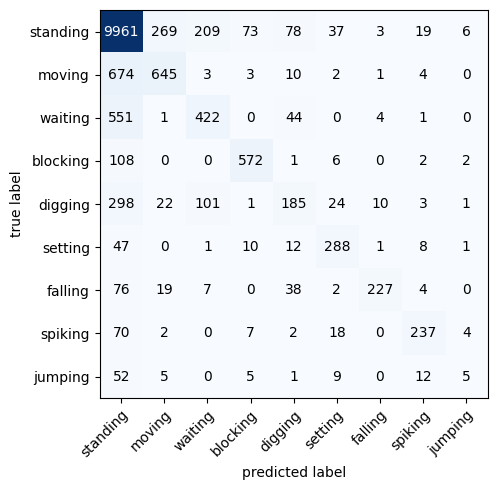

In [56]:
Display_Confusion_matrix(y_true, y_preds, model_config.classes_names)

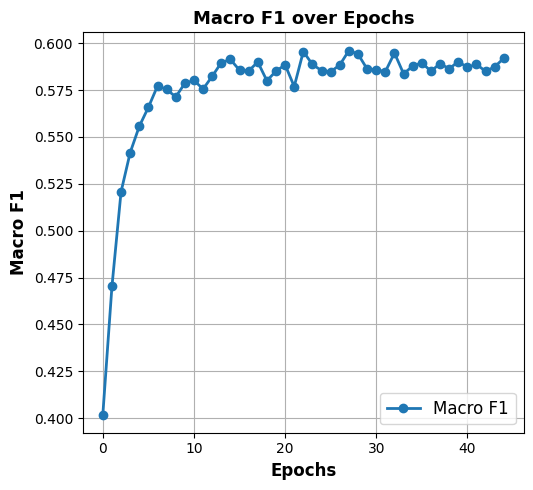

In [53]:
Display_confusion_matrix_and_macrof1(epoch_values, macro_f1_values, r"/kaggle/working/Figures")

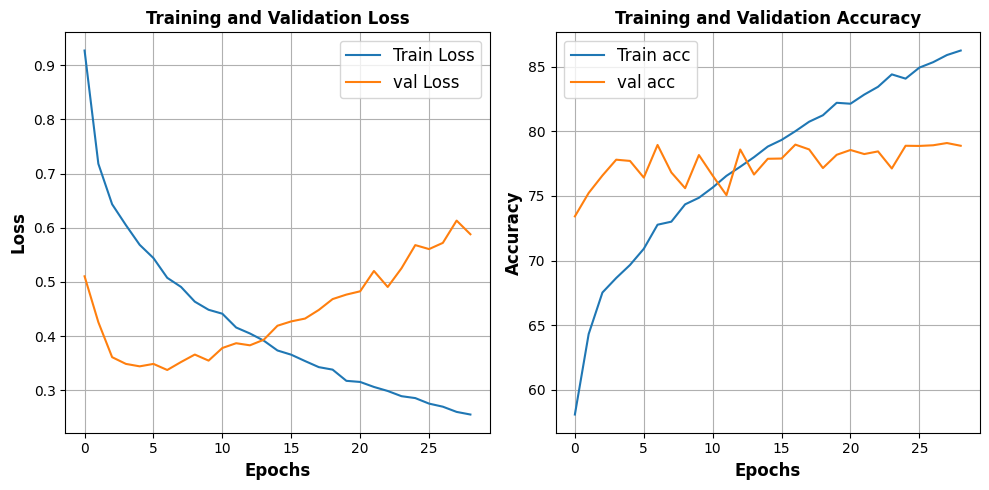

In [54]:
Display_train_eval_curves(epoch_values[:29], train_losses_values[:29], val_losses_values[:29], train_acc_values[:29], val_acc_values[:29])

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Thanks & Upvote ❤️</div>